# W-KMEDOIDS — SEGMENTACIÓN ELECTORAL

### INICIALIZACIÓN

In [8]:
import sys
from pathlib import Path

project_root = Path.cwd().parent.parent
sys.path.insert(0, str(project_root))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

from src.clustering.weighted import WKMedoids
from src.weighting.weight_manager import WeightManager
from src.evaluation import calculate_metrics
from src.utils.constants import PROCESSED_DATA_PATH, RESULTS_PATH

sns.set_style('whitegrid')
np.random.seed(42)

print('='*70)
print('W-KMEDOIDS — SEGMENTACIÓN ELECTORAL')
print('='*70)

W-KMEDOIDS — SEGMENTACIÓN ELECTORAL


### CARGA DE DATOS Y PESOS

In [9]:
# Dataset electoral preprocesado
df = pd.read_csv(PROCESSED_DATA_PATH)

print(f'\n✓ Dataset cargado: {df.shape[0]} registros × {df.shape[1]} variables')
print(f'  Missings: {df.isnull().sum().sum()}')

# Esquema de ponderación
wm = WeightManager()
wm.print_summary()

print('='*70)


✓ Dataset cargado: 1706 registros × 28 variables
  Missings: 0
Pesos cargados desde c:\electocluster\src\weighting\schemas\feature_weights.json, total de características: 42.

  WeightManager — c:\electocluster\src\weighting\schemas\feature_weights.json
  Features: 42
  edre                 1.00  ■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■
  q10inc               1.00  ■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■
  etid                 0.75  ■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■
  boletidnew           0.70  ■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■
  boletidnewb          0.70  ■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■
  estratopri           0.85  ■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■■
  ur                   0.90  ■■■■■■■■■■■■■■■■■■■■■

### CONFIGURACIÓN Y EJECUCIÓN

In [10]:
# Configuración del modelo
N_CLUSTERS = 2 # N Clusters es 2 por que fue el valor obtenido como el "mejor" en iteration2/03_clustering_dataset_electoral_test

modelo = WKMedoids(
    n_clusters=N_CLUSTERS,
    metric='precomputed',
    method='pam',
    max_iter=300,
    random_state=42,
    weight_manager=wm
)

modelo.fit(df)
metricas = calculate_metrics(df, modelo.labels_)

print(f'\n✓ MÉTRICAS DE VALIDACIÓN:')
print(f"  Silhouette Score:        {metricas['silhouette']:.4f}")
print(f"  Davies-Bouldin Index:    {metricas['davies_bouldin']:.4f}")
print(f"  Calinski-Harabasz Index: {metricas['calinski_harabasz']:.4f}")

print(f'\n✓ DISTRIBUCIÓN DE CLUSTERS:')
distribucion = pd.Series(modelo.labels_).value_counts().sort_index()
for cluster, n in distribucion.items():
    pct = n / len(modelo.labels_) * 100
    print(f'  Cluster {cluster}: {n:>5} registros ({pct:.1f}%)')

print('\n' + '='*70)

Entrenando Weighted K-Medoids con 2 clusters...
✓ WK-Medoids entrenado: 2 clusters identificados
  Inercia: 2476.4848
Calculando métricas de validación...
  Muestras: 1706
  Clusters: 2
  ✓ Silhouette Score: 0.0881
  ✓ Davies-Bouldin Index: 3.1689
  ✓ Calinski-Harabasz Index: 162.7175

✓ MÉTRICAS DE VALIDACIÓN:
  Silhouette Score:        0.0881
  Davies-Bouldin Index:    3.1689
  Calinski-Harabasz Index: 162.7175

✓ DISTRIBUCIÓN DE CLUSTERS:
  Cluster 0:   962 registros (56.4%)
  Cluster 1:   744 registros (43.6%)



### VISUALIZACIÓN DE CLUSTERS

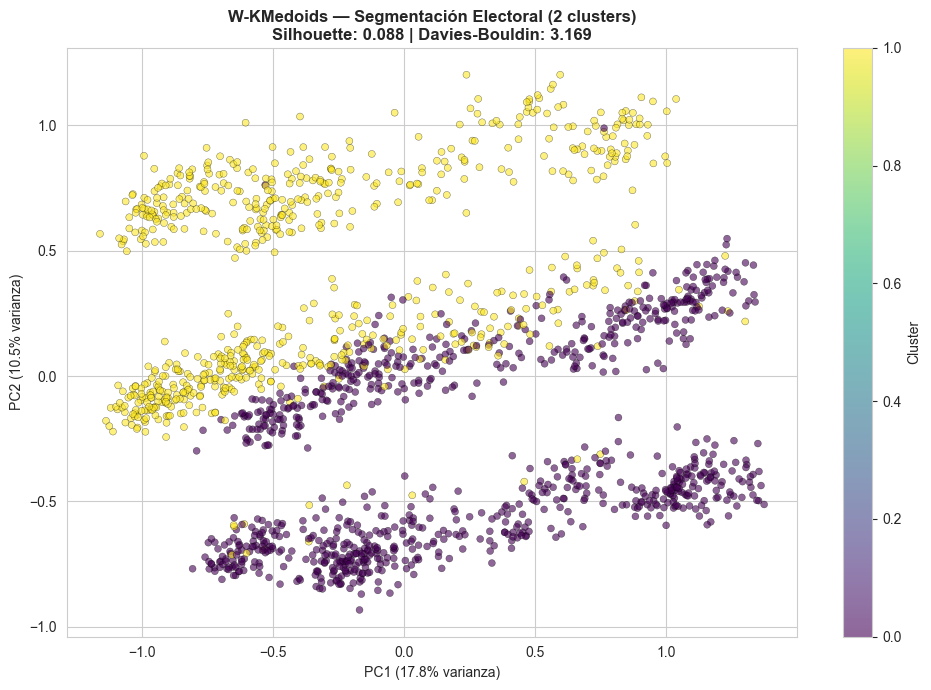

  Varianza explicada por PC1+PC2: 28.2%


In [11]:
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(df)

fig, ax = plt.subplots(figsize=(10, 7))

scatter = ax.scatter(
    X_2d[:, 0], X_2d[:, 1],
    c=modelo.labels_,
    cmap='viridis',
    alpha=0.6,
    s=25,
    edgecolors='black',
    linewidth=0.3
)

plt.colorbar(scatter, ax=ax, label='Cluster')
ax.set_title(
    f'W-KMedoids — Segmentación Electoral ({N_CLUSTERS} clusters)\n'
    f'Silhouette: {metricas["silhouette"]:.3f} | Davies-Bouldin: {metricas["davies_bouldin"]:.3f}',
    fontweight='bold'
)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% varianza)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% varianza)')

plt.tight_layout()
plt.savefig(f'{RESULTS_PATH}/clustering/wkmedoids_clusters_electoral.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'  Varianza explicada por PC1+PC2: {pca.explained_variance_ratio_.sum()*100:.1f}%')
print('='*70)

### MEDOIDES — PERFIL DE CADA SEGMENTO


✓ MEDOIDES (votante representativo de cada cluster):
  Índices en el dataset: [1119, 621]

               1119   621 
edre          0.833  0.667
q10inc        0.071  0.143
etid          0.400  0.200
boletidnew    1.000  0.000
boletidnewb   0.000  0.000
estratopri    0.200  0.600
ur            1.000  1.000
ocupoit       0.556  0.556
q2            0.186  0.129
q1tc_r        0.500  0.000
q3cn          0.000  0.000
q5b           0.000  0.000
leng1         0.000  0.000
formal        0.000  0.000
wf1           0.000  0.000
bolcct1a      0.000  1.000
bolcct1b      1.000  0.000
bolcct1c      0.000  0.000
estratosec    0.500  0.500
q12cn         0.083  0.250
q12bn         0.000  0.200
gi0n          0.250  0.250
smedia3n      0.500  0.250
q10e          0.500  0.500
q11n          0.000  0.000
leng4         0.250  0.000
wealth_index  0.400  0.400
civic_index   0.167  0.250


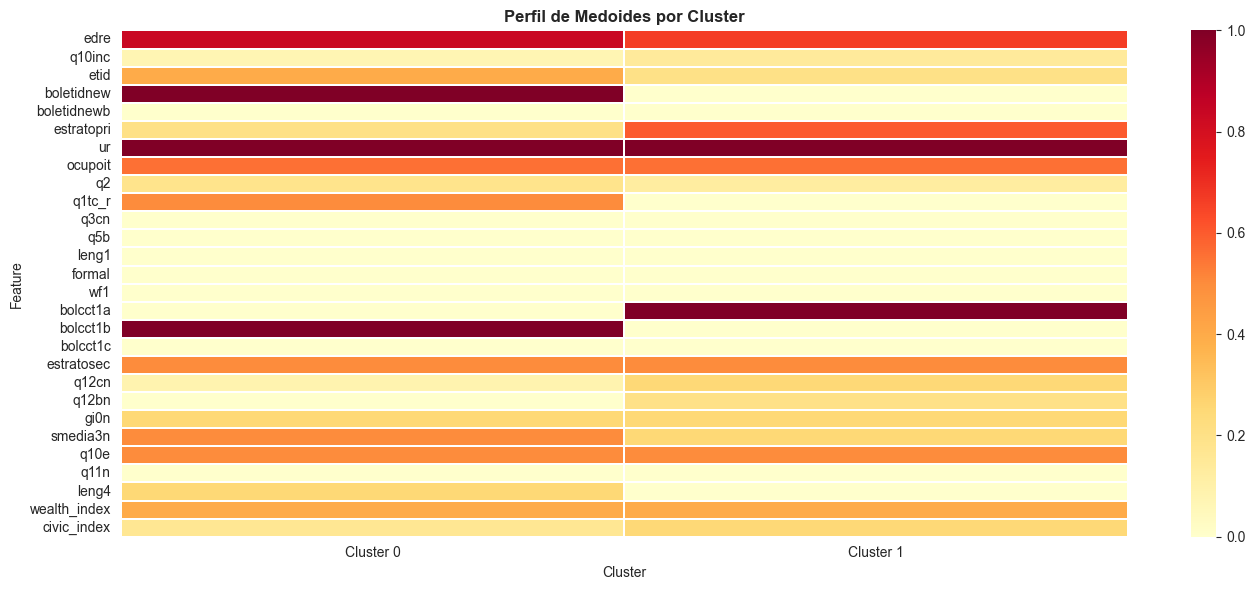

In [12]:
medoides = modelo.get_medoids(df)

print(f'\n✓ MEDOIDES (votante representativo de cada cluster):')
print(f'  Índices en el dataset: {modelo.medoid_indices_.tolist()}')
print()
print(medoides.round(3).T.to_string())

# Heatmap de medoides
fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(
    medoides.T,
    ax=ax,
    cmap='YlOrRd',
    annot=False,
    linewidths=0.3,
    xticklabels=[f'Cluster {i}' for i in range(N_CLUSTERS)],
    yticklabels=df.columns.tolist()
)
ax.set_title('Perfil de Medoides por Cluster', fontweight='bold')
ax.set_xlabel('Cluster')
ax.set_ylabel('Feature')

plt.tight_layout()
plt.savefig(f'{RESULTS_PATH}/clustering/wkmedoids_medoides_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print('='*70)

### PERFIL SOCIOPOLÍTICO DE CLUSTERS

In [13]:
df_resultado = df.copy()
df_resultado['cluster'] = modelo.labels_

resumen = df_resultado.groupby('cluster').mean()

print(f'\n✓ MEDIA DE VARIABLES POR CLUSTER:')
print(resumen.round(3).to_string())

# Guardar resultados
df_resultado.to_csv(f'{RESULTS_PATH}/clustering/wkmedoids_resultado_electoral.csv', index=False)
resumen.to_csv(f'{RESULTS_PATH}/clustering/wkmedoids_perfil_clusters.csv')

print(f'\n✓ Resultados guardados en {RESULTS_PATH}/clustering/')
print('='*70)


✓ MEDIA DE VARIABLES POR CLUSTER:
          edre  q10inc   etid  boletidnew  boletidnewb  estratopri     ur  ocupoit     q2  q1tc_r   q3cn    q5b  leng1  formal    wf1  bolcct1a  bolcct1b  bolcct1c  estratosec  q12cn  q12bn   gi0n  smedia3n   q10e   q11n  leng4  wealth_index  civic_index
cluster                                                                                                                                                                                                                                                       
0        0.646   0.206  0.267       0.785        0.142       0.418  0.620    0.600  0.277   0.260  0.223  0.159  0.100   0.136  0.063     0.215     0.792     0.159       0.535  0.171   0.16  0.192     0.249  0.637  0.215  0.223         0.573        0.300
1        0.689   0.240  0.231       0.261        0.048       0.456  0.769    0.569  0.390   0.222  0.180  0.157  0.067   0.136  0.086     0.681     0.222     0.071       0.378  0.142   0.08  0.177    